In [31]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from pathlib import Path
import numpy as np
import re
import pandas as pd

In [32]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

with open(
    "FinancialPhraseBank/FinancialPhraseBank-v1.0/Sentences_50Agree.txt",
    encoding="latin-1"
) as sentences_file:
    raw_sentences = sentences_file.read()

sentences_list_with_sentiments = raw_sentences.split("\n")[:-1]

sentences_list = []
y = []
sentiment_dictionary = {"negative": 2, "neutral": 0, "positive": 1}

for sentence in sentences_list_with_sentiments:
    text, sentiment = sentence.rsplit('@', 1)
    sentences_list.append(text)
    y.append(sentiment_dictionary[sentiment])
y = np.array(y)

def preprocess_sentences(sentences_list):
    sentences_list_all_lower = [sentence.lower() for sentence in sentences_list]

    noise_characters_dict = {"%": "", ",":"", "(":"", ")":"", ":":"", "n't":" not", "'s":"", "€":"", "$":"", "``":"", "''":"", "...":"", "`":"", "'":"" ,"  ":" "}
    sentences_list_denoised = sentences_list_all_lower
    for noise_character, replace_character in noise_characters_dict.items():
        sentences_list_denoised = [sentence.replace(noise_character, replace_character) for sentence in sentences_list_denoised]

    nltk_stop_words = set(stopwords.words('english'))
    not_stop_words = {"above", "after", "against", "before", "below", "between", "down", "from", "no", "not", "nor", "off", "only", "over", "same", "to", "under", "up"}
    additional_stop_words = {"bln", "mln", "pct", "percent"}
    stop_words = (nltk_stop_words - not_stop_words).union(additional_stop_words)
    # stop_words = (nltk_stop_words - not_stop_words)
    sentences_list_without_stop_words = []
    for sentence in sentences_list_denoised:
        words_list = word_tokenize(sentence)
        sentence_without_stop_words = " ".join([word for word in words_list if word not in stop_words])
        sentences_list_without_stop_words.append(sentence_without_stop_words)
    
    lemmatizer = WordNetLemmatizer()
    sentences_list_lemmatized = []
    for sentence in sentences_list_without_stop_words:
        words_list = word_tokenize(sentence)
        sentence_lemmatized = " ".join([lemmatizer.lemmatize(word) for word in words_list])
        sentences_list_lemmatized.append(sentence_lemmatized)

    sentences_list_only_ascii = sentences_list_lemmatized
    sentences_list_only_ascii = [re.sub(r'[^.a-zA-Z0-9\s<>\-]', '', sentence) for sentence in sentences_list_only_ascii]

    sentences_list_without_numbers = []
    for sentence in sentences_list_only_ascii:
        sentence_without_numbers = re.sub(r'\b\d+\s*(?:[\.,]\s*\d+)?\b', ' <NUM> ', sentence).replace(".", "").replace("-", " ").replace("  ", " ")
        sentences_list_without_numbers.append(sentence_without_numbers)
    
    return sentences_list_all_lower, sentences_list_denoised, sentences_list_without_stop_words, sentences_list_lemmatized, sentences_list_only_ascii, sentences_list_without_numbers

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/theohagen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/theohagen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/theohagen/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/theohagen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [33]:
_, _, _, _, _, X = preprocess_sentences(sentences_list)

### Some more conditionals

In [34]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

### Creating Train/Val/Test Splits:

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=43,
    shuffle=True,
    stratify=y
)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

bow_vectorizer = CountVectorizer()

X_train_bow_t = torch.tensor(bow_vectorizer.fit_transform(X_train).toarray(), dtype=torch.float32)
X_test_bow_t = torch.tensor(bow_vectorizer.transform(X_test).toarray(), dtype=torch.float32)

tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf_t = torch.tensor(tfidf_vectorizer.fit_transform(X_train).toarray(), dtype=torch.float32)
X_test_tfidf_t = torch.tensor(tfidf_vectorizer.transform(X_test).toarray(), dtype=torch.float32)

print(X_train_bow_t.shape, X_test_bow_t.shape)
print(X_train_tfidf_t.shape, X_test_tfidf_t.shape)
print(y_train.shape, y_test.shape)

torch.Size([3876, 7635]) torch.Size([970, 7635])
torch.Size([3876, 7635]) torch.Size([970, 7635])
(3876,) (970,)


### Feed-Forward Neural Network

In [36]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [37]:
def run_model(train_loader, test_loader, epochs=5, lr=0.001, num_classes = 3, target_names=["neutral", "positive", "negative"]):  
    input_dim = train_loader.dataset.tensors[0].shape[1]

    model = FeedForwardNN(
        input_dim=input_dim,
        hidden_dim=32,
        num_classes=num_classes
    )

    loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    for epoch in range(epochs):
        # ---------- Training ----------
        model.train()
        total_train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            logits = model(X_batch)
            batch_loss = loss(logits, y_batch)

            batch_loss.backward()
            optimizer.step()

            total_train_loss += batch_loss.item() * X_batch.size(0)

        avg_train_loss = total_train_loss / len(train_loader.dataset)

        # ---------- Validation ----------
        model.eval()
        total_val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                logits = model(X_batch)
                batch_loss = loss(logits, y_batch)

                total_val_loss += batch_loss.item() * X_batch.size(0)

                preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        avg_val_loss = total_val_loss / len(test_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average="macro")

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Test Loss: {avg_val_loss:.4f} | "
            f"Test Acc: {val_acc:.4f} | "
            f"Test Macro-F1: {val_f1:.4f}"
        )

    # ---------- Report ----------
    print("\nClassification Report:")
    print(classification_report(
        all_labels,
        all_preds,
        labels=list(range(num_classes)),
        target_names=target_names,
        zero_division=0
    ))

    return all_labels, all_preds

### Bag of Words

In [38]:
train_dataset = TensorDataset(X_train_bow_t, y_train_t)
test_dataset = TensorDataset(X_test_bow_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

bow_true, bow_pred = run_model(train_loader, test_loader)

Epoch 1/5 | Train Loss: 0.9540 | Test Loss: 0.7880 | Test Acc: 0.6763 | Test Macro-F1: 0.4150
Epoch 2/5 | Train Loss: 0.6719 | Test Loss: 0.6589 | Test Acc: 0.7412 | Test Macro-F1: 0.6172
Epoch 3/5 | Train Loss: 0.4823 | Test Loss: 0.5979 | Test Acc: 0.7526 | Test Macro-F1: 0.6660
Epoch 4/5 | Train Loss: 0.3455 | Test Loss: 0.5791 | Test Acc: 0.7608 | Test Macro-F1: 0.6879
Epoch 5/5 | Train Loss: 0.2622 | Test Loss: 0.5815 | Test Acc: 0.7598 | Test Macro-F1: 0.6927

Classification Report:
              precision    recall  f1-score   support

     neutral       0.78      0.89      0.83       576
    positive       0.69      0.62      0.65       273
    negative       0.78      0.48      0.59       121

    accuracy                           0.76       970
   macro avg       0.75      0.66      0.69       970
weighted avg       0.76      0.76      0.75       970



### Tfidf

In [39]:
train_dataset = TensorDataset(X_train_tfidf_t, y_train_t)
test_dataset = TensorDataset(X_test_tfidf_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

tfidf_true, tfidf_pred = run_model(train_loader, test_loader, epochs=8)

Epoch 1/8 | Train Loss: 0.9835 | Test Loss: 0.8538 | Test Acc: 0.6371 | Test Macro-F1: 0.3464
Epoch 2/8 | Train Loss: 0.7803 | Test Loss: 0.7393 | Test Acc: 0.6773 | Test Macro-F1: 0.4175
Epoch 3/8 | Train Loss: 0.6424 | Test Loss: 0.6727 | Test Acc: 0.7155 | Test Macro-F1: 0.5349
Epoch 4/8 | Train Loss: 0.5191 | Test Loss: 0.6286 | Test Acc: 0.7454 | Test Macro-F1: 0.6438
Epoch 5/8 | Train Loss: 0.4179 | Test Loss: 0.6049 | Test Acc: 0.7423 | Test Macro-F1: 0.6520
Epoch 6/8 | Train Loss: 0.3415 | Test Loss: 0.5918 | Test Acc: 0.7505 | Test Macro-F1: 0.6678
Epoch 7/8 | Train Loss: 0.2890 | Test Loss: 0.5872 | Test Acc: 0.7588 | Test Macro-F1: 0.6931
Epoch 8/8 | Train Loss: 0.2427 | Test Loss: 0.5884 | Test Acc: 0.7649 | Test Macro-F1: 0.7009

Classification Report:
              precision    recall  f1-score   support

     neutral       0.79      0.89      0.84       576
    positive       0.70      0.61      0.65       273
    negative       0.75      0.52      0.61       121

    ac

### Confusion Matrix

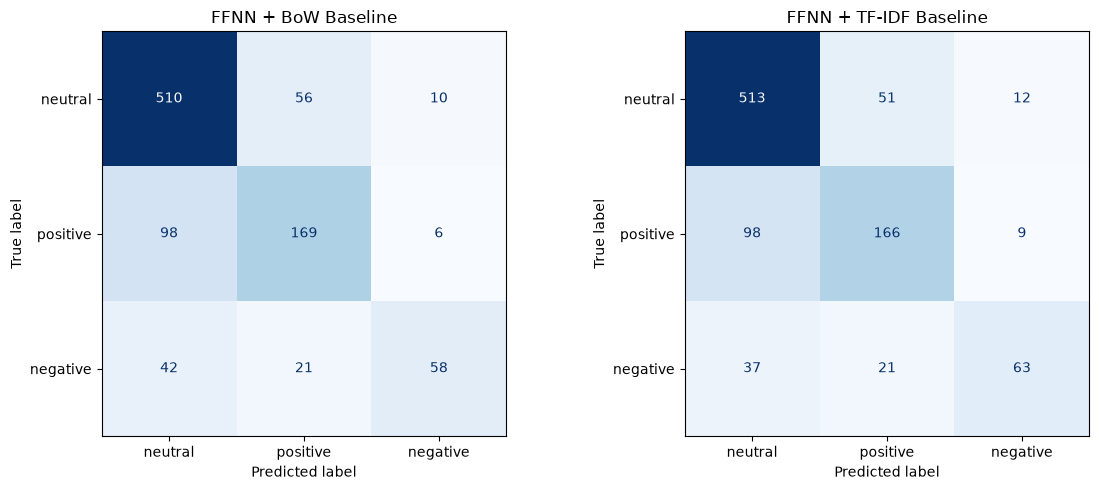

In [40]:
class_names = ["neutral", "positive", "negative"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    bow_true,
    bow_pred,
    labels=[0, 1, 2],
    display_labels=class_names,
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)

axes[0].set_title("FFNN + BoW Baseline")

ConfusionMatrixDisplay.from_predictions(
    tfidf_true,
    tfidf_pred,
    labels=[0, 1, 2],
    display_labels=class_names,
    cmap="Blues",
    ax=axes[1],
    colorbar=False
)

axes[1].set_title("FFNN + TF-IDF Baseline")

plt.tight_layout()
plt.show()

### Oversampling

In [41]:
df_train = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

max_class_size = df_train["label"].value_counts().max()
oversampled = []

for label in df_train["label"].unique():
    class_df = df_train[df_train["label"] == label]

    label_oversample = resample(
        class_df,
        replace=True,
        n_samples=max_class_size,
        random_state=43
    )

    oversampled.append(label_oversample)

df_oversampled = pd.concat(oversampled)
df_oversampled = df_oversampled.sample(frac=1, random_state=43).reset_index(drop=True)

df_oversampled["label"].value_counts()

label
2    2303
0    2303
1    2303
Name: count, dtype: int64

### FFNN + BoW + Oversampling

In [42]:
X_train_bow_over_t = torch.tensor(
    bow_vectorizer.transform(df_oversampled["text"]).toarray(),
    dtype=torch.float32
)

y_train_over_t = torch.tensor(
    df_oversampled["label"].values,
    dtype=torch.long
)

train_dataset = TensorDataset(X_train_bow_over_t, y_train_over_t)
test_dataset = TensorDataset(X_test_bow_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("FFNN + BoW + Oversampling")
_, _ = run_model(train_loader, test_loader, epochs=5, lr=0.0005)

FFNN + BoW + Oversampling
Epoch 1/5 | Train Loss: 0.9552 | Test Loss: 0.8816 | Test Acc: 0.6804 | Test Macro-F1: 0.6113
Epoch 2/5 | Train Loss: 0.5830 | Test Loss: 0.6847 | Test Acc: 0.7443 | Test Macro-F1: 0.6893
Epoch 3/5 | Train Loss: 0.3565 | Test Loss: 0.6063 | Test Acc: 0.7505 | Test Macro-F1: 0.7046
Epoch 4/5 | Train Loss: 0.2439 | Test Loss: 0.5802 | Test Acc: 0.7536 | Test Macro-F1: 0.7107
Epoch 5/5 | Train Loss: 0.1794 | Test Loss: 0.5671 | Test Acc: 0.7526 | Test Macro-F1: 0.7014

Classification Report:
              precision    recall  f1-score   support

     neutral       0.82      0.82      0.82       576
    positive       0.65      0.68      0.67       273
    negative       0.65      0.59      0.62       121

    accuracy                           0.75       970
   macro avg       0.71      0.70      0.70       970
weighted avg       0.75      0.75      0.75       970



### FFNN + TFIDF + Oversampling

In [43]:
X_train_tfidf_over_t = torch.tensor(
    tfidf_vectorizer.transform(df_oversampled["text"]).toarray(),
    dtype=torch.float32
)

y_train_over_t = torch.tensor(
    df_oversampled["label"].values,
    dtype=torch.long
)

train_dataset = TensorDataset(X_train_tfidf_over_t, y_train_over_t)
test_dataset = TensorDataset(X_test_tfidf_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("FFNN + TF-IDF + Oversampling")
_, _ = run_model(train_loader, test_loader, epochs=5)

FFNN + TF-IDF + Oversampling
Epoch 1/5 | Train Loss: 0.9637 | Test Loss: 0.8842 | Test Acc: 0.6649 | Test Macro-F1: 0.6214
Epoch 2/5 | Train Loss: 0.5778 | Test Loss: 0.6746 | Test Acc: 0.7278 | Test Macro-F1: 0.6754
Epoch 3/5 | Train Loss: 0.3431 | Test Loss: 0.5996 | Test Acc: 0.7443 | Test Macro-F1: 0.7011
Epoch 4/5 | Train Loss: 0.2279 | Test Loss: 0.5757 | Test Acc: 0.7577 | Test Macro-F1: 0.7112
Epoch 5/5 | Train Loss: 0.1616 | Test Loss: 0.5814 | Test Acc: 0.7495 | Test Macro-F1: 0.7066

Classification Report:
              precision    recall  f1-score   support

     neutral       0.84      0.79      0.82       576
    positive       0.63      0.71      0.67       273
    negative       0.65      0.62      0.64       121

    accuracy                           0.75       970
   macro avg       0.71      0.71      0.71       970
weighted avg       0.76      0.75      0.75       970



### Undersampling

In [44]:
min_class_size = df_train["label"].value_counts().min()
undersampled = []

for label in df_train["label"].unique():
    class_df = df_train[df_train["label"] == label]

    label_undersample = resample(
        class_df,
        replace=False,
        n_samples=min_class_size,
        random_state=43
    )

    undersampled.append(label_undersample)

df_undersampled = pd.concat(undersampled)
df_undersampled = df_undersampled.sample(frac=1, random_state=43).reset_index(drop=True)

df_undersampled["label"].value_counts()

label
2    483
0    483
1    483
Name: count, dtype: int64

### FFNN + BoW + Undersampling

In [45]:
X_train_bow_under_t = torch.tensor(
    bow_vectorizer.transform(df_undersampled["text"]).toarray(),
    dtype=torch.float32
)

y_train_under_t = torch.tensor(
    df_undersampled["label"].values,
    dtype=torch.long
)

train_dataset = TensorDataset(X_train_bow_under_t, y_train_under_t)
test_dataset = TensorDataset(X_test_bow_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("FFNN + BoW + Undersampling")
_, _ = run_model(train_loader, test_loader, epochs=7)

FFNN + BoW + Undersampling
Epoch 1/7 | Train Loss: 1.0761 | Test Loss: 1.0651 | Test Acc: 0.5062 | Test Macro-F1: 0.3858
Epoch 2/7 | Train Loss: 0.9513 | Test Loss: 0.9731 | Test Acc: 0.6093 | Test Macro-F1: 0.5506
Epoch 3/7 | Train Loss: 0.7571 | Test Loss: 0.8762 | Test Acc: 0.6412 | Test Macro-F1: 0.5931
Epoch 4/7 | Train Loss: 0.5787 | Test Loss: 0.7968 | Test Acc: 0.6825 | Test Macro-F1: 0.6426
Epoch 5/7 | Train Loss: 0.4294 | Test Loss: 0.7373 | Test Acc: 0.6959 | Test Macro-F1: 0.6609
Epoch 6/7 | Train Loss: 0.3227 | Test Loss: 0.7102 | Test Acc: 0.6990 | Test Macro-F1: 0.6730
Epoch 7/7 | Train Loss: 0.2587 | Test Loss: 0.7199 | Test Acc: 0.6938 | Test Macro-F1: 0.6622

Classification Report:
              precision    recall  f1-score   support

     neutral       0.86      0.68      0.76       576
    positive       0.57      0.70      0.63       273
    negative       0.51      0.74      0.60       121

    accuracy                           0.69       970
   macro avg       

### FFNN + Tfidf + Undersampling

In [46]:
X_train_tfidf_under_t = torch.tensor(
    tfidf_vectorizer.transform(df_undersampled["text"]).toarray(),
    dtype=torch.float32
)

y_train_under_t = torch.tensor(
    df_undersampled["label"].values,
    dtype=torch.long
)

train_dataset = TensorDataset(X_train_tfidf_under_t, y_train_under_t)
test_dataset = TensorDataset(X_test_tfidf_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("FFNN + Tfidf + Undersampling")
_, _ = run_model(train_loader, test_loader, epochs=16)

FFNN + Tfidf + Undersampling
Epoch 1/16 | Train Loss: 1.1030 | Test Loss: 1.1030 | Test Acc: 0.2814 | Test Macro-F1: 0.1464
Epoch 2/16 | Train Loss: 1.0608 | Test Loss: 1.0653 | Test Acc: 0.2722 | Test Macro-F1: 0.2528
Epoch 3/16 | Train Loss: 0.9750 | Test Loss: 1.0031 | Test Acc: 0.6031 | Test Macro-F1: 0.5590
Epoch 4/16 | Train Loss: 0.8603 | Test Loss: 0.9334 | Test Acc: 0.6495 | Test Macro-F1: 0.5745
Epoch 5/16 | Train Loss: 0.7497 | Test Loss: 0.8670 | Test Acc: 0.6711 | Test Macro-F1: 0.5988
Epoch 6/16 | Train Loss: 0.6348 | Test Loss: 0.8486 | Test Acc: 0.6598 | Test Macro-F1: 0.6135
Epoch 7/16 | Train Loss: 0.5351 | Test Loss: 0.7844 | Test Acc: 0.6897 | Test Macro-F1: 0.6519
Epoch 8/16 | Train Loss: 0.4435 | Test Loss: 0.7525 | Test Acc: 0.6969 | Test Macro-F1: 0.6593
Epoch 9/16 | Train Loss: 0.3784 | Test Loss: 0.7267 | Test Acc: 0.7082 | Test Macro-F1: 0.6732
Epoch 10/16 | Train Loss: 0.3216 | Test Loss: 0.7135 | Test Acc: 0.7093 | Test Macro-F1: 0.6756
Epoch 11/16 | Train 

### Binary FFNN with BoW

In [47]:
df_train_binary = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

df_test_binary = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

df_train_binary = df_train_binary[df_train_binary["label"] != 0].copy()
df_test_binary = df_test_binary[df_test_binary["label"] != 0].copy()

binary_mapping = {
    2: 0,
    1: 1
}

df_train_binary["label"] = df_train_binary["label"].map(binary_mapping)
df_test_binary["label"] = df_test_binary["label"].map(binary_mapping)

print("Binary train distribution:")
print(df_train_binary["label"].value_counts())

print("\nBinary test distribution:")
print(df_test_binary["label"].value_counts())

Binary train distribution:
label
1    1090
0     483
Name: count, dtype: int64

Binary test distribution:
label
1    273
0    121
Name: count, dtype: int64


In [48]:
bow_vectorizer_binary = CountVectorizer()

X_train_bow_binary = bow_vectorizer_binary.fit_transform(df_train_binary["text"])
X_test_bow_binary = bow_vectorizer_binary.transform(df_test_binary["text"])

X_train_bow_binary_t = torch.tensor(
    X_train_bow_binary.toarray(),
    dtype=torch.float32
)

X_test_bow_binary_t = torch.tensor(
    X_test_bow_binary.toarray(),
    dtype=torch.float32
)

y_train_binary_t = torch.tensor(
    df_train_binary["label"].values,
    dtype=torch.long
)

y_test_binary_t = torch.tensor(
    df_test_binary["label"].values,
    dtype=torch.long
)

train_dataset_binary_bow = TensorDataset(
    X_train_bow_binary_t,
    y_train_binary_t
)

test_dataset_binary_bow = TensorDataset(
    X_test_bow_binary_t,
    y_test_binary_t
)

train_loader_binary_bow = DataLoader(
    train_dataset_binary_bow,
    batch_size=32,
    shuffle=True
)

test_loader_binary_bow = DataLoader(
    test_dataset_binary_bow,
    batch_size=32,
    shuffle=False
)

In [49]:
_, _ = run_model(
    train_loader_binary_bow,
    test_loader_binary_bow,
    epochs=7,
    num_classes=2,
    target_names=["negative", "positive"]
)

Epoch 1/7 | Train Loss: 0.6510 | Test Loss: 0.5824 | Test Acc: 0.6929 | Test Macro-F1: 0.4093
Epoch 2/7 | Train Loss: 0.5046 | Test Loss: 0.4778 | Test Acc: 0.7741 | Test Macro-F1: 0.6589
Epoch 3/7 | Train Loss: 0.3528 | Test Loss: 0.3902 | Test Acc: 0.8376 | Test Macro-F1: 0.7812
Epoch 4/7 | Train Loss: 0.2295 | Test Loss: 0.3414 | Test Acc: 0.8503 | Test Macro-F1: 0.8055
Epoch 5/7 | Train Loss: 0.1568 | Test Loss: 0.3216 | Test Acc: 0.8629 | Test Macro-F1: 0.8268
Epoch 6/7 | Train Loss: 0.1144 | Test Loss: 0.3176 | Test Acc: 0.8680 | Test Macro-F1: 0.8332
Epoch 7/7 | Train Loss: 0.0892 | Test Loss: 0.3278 | Test Acc: 0.8680 | Test Macro-F1: 0.8312

Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.65      0.75       121
    positive       0.86      0.96      0.91       273

    accuracy                           0.87       394
   macro avg       0.87      0.81      0.83       394
weighted avg       0.87      0.87      0.86   